# P1: Import of the data

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import glob
import os
import seaborn as sns
import tensorflow as tf
import cv2
from tensorflow.python.client import device_lib
import kagglehub

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [2]:
import keras
print(keras.__version__)

3.14.1


In [41]:
def evaluate_metric(y_true, y_pred, class_names):
    
    cm = confusion_matrix(y_true, y_pred)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Affichage de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    return metrics

In [15]:
train_dataset_main = "../data/train"
test_dataset_main = "../data/test"
valid_dataset_main = "..//data/valid"

In [4]:
# Tiryaki, S. (s.d.). Facial Expressions Classification. 
# Link: https://www.kaggle.com/code/sahintiryaki/facial-expressions-classification
def create_dataset_df(main_path, dataset_name):
    print(f"{dataset_name} is creating ...")
    df = {"img_path":[],"class_names":[]}
    for class_names in os.listdir(main_path):
        # Select only the emotions we want to detect.
        if class_names in {"happy", "angry", "neutral", "sad", "surprise"}:
            for img_path in glob.glob(f"{main_path}/{class_names}/*"):
                df["img_path"].append(img_path)
                df["class_names"].append(class_names)
    df = pd.DataFrame(df)
    print(f"{dataset_name} is created !")
    return df

In [5]:
train_df = create_dataset_df(train_dataset_main, "Train dataset")
train_df.size

Train dataset is creating ...
Train dataset is created !


169756

In [6]:
test_df = create_dataset_df(test_dataset_main, "Test dataset")
test_df.size

Test dataset is creating ...
Test dataset is created !


32020

In [7]:
valid_df = create_dataset_df(valid_dataset_main, "Valid dataset")
valid_df.size

Valid dataset is creating ...
Valid dataset is created !


32082

In [8]:
train_df.head()

,img_path,class_names
0,../data/train/happy/86825Exp3astound_teacher_9...,happy
1,../data/train/happy/Happy.19696.jpg,happy
2,../data/train/happy/Happy.8956.jpg,happy
3,../data/train/happy/68317Exp3awe_grandmother_4...,happy
4,../data/train/happy/66277Exp3awe_boss_643.jpg,happy


In [9]:
def vizualizing_images(df,n_rows,n_cols):
    plt.figure(figsize=(10,10))
    for i in range(n_rows*n_cols):
        index = np.random.randint(0, len(df))
        img = cv2.imread(df.img_path[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        class_nm = df.class_names[index]
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img, plt.cm.gray)
        plt.title(class_nm)
    plt.show()

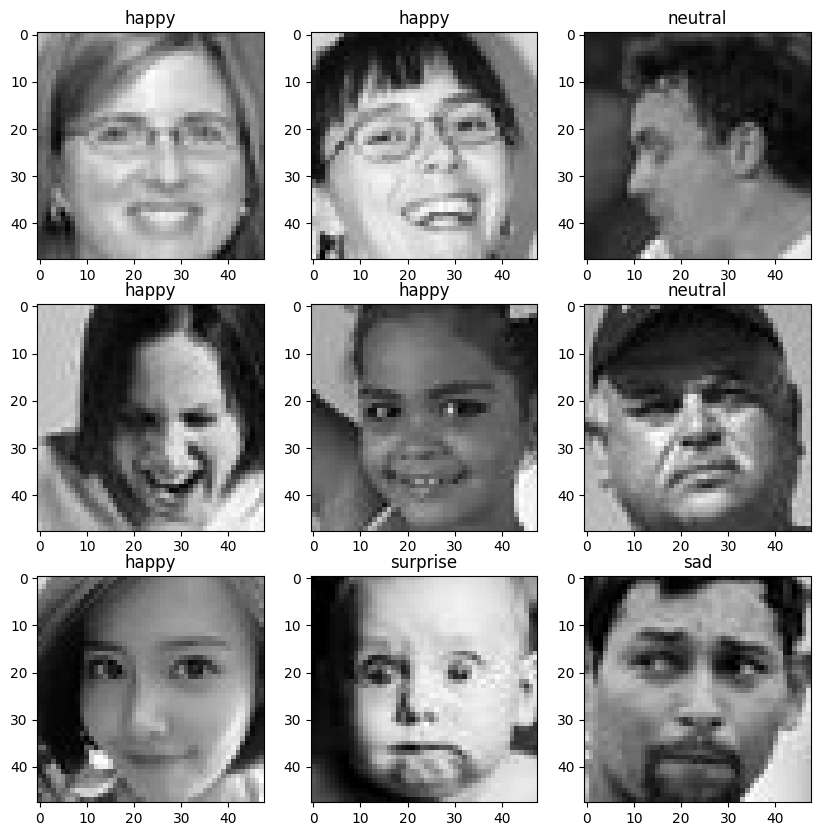

In [10]:
vizualizing_images(train_df, 3, 3)

# P2: Build the CNN (ResNet)

In [11]:
#https://github.com/tensorflow/tpu/tree/master/models/official/efficientnet

In [12]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
BATCH_SIZE = 64
EPOCHS = 40
IMG_CHANNEL = 3
IMG_W, IMG_H = 150, 150

In [35]:
# EfficientNet BO as a model
B_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_W, IMG_H, 3),
)

In [36]:
B_model.trainable = False

In [38]:
inputs = keras.Input(shape=(IMG_W, IMG_H, 3))

x = B_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_emotion")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "efficientnet_emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [48]:
# Entrainement
train_datagen = ImageDataGenerator(
    rescale = 1/.255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(150, 150),
    batch_size=64,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(IMG_W, IMG_H),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=valid_generator,
    callbacks=[early_stopping]
)

Found 84878 validated image filenames belonging to 5 classes.
Found 16010 validated image filenames belonging to 5 classes.
Epoch 1/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 837s 623ms/step - accuracy: 0.2917 - loss: 5.8103 - val_accuracy: 0.3252 - val_loss: 1.6562
Epoch 2/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 834s 628ms/step - accuracy: 0.3252 - loss: 1.8924 - val_accuracy: 0.3517 - val_loss: 1.5453
Epoch 3/40
  56/1327 ━━━━━━━━━━━━━━━━━━━━ 11:57 564ms/step - accuracy: 0.3376 - loss: 1.8841

KeyboardInterrupt: 

251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 495ms/step


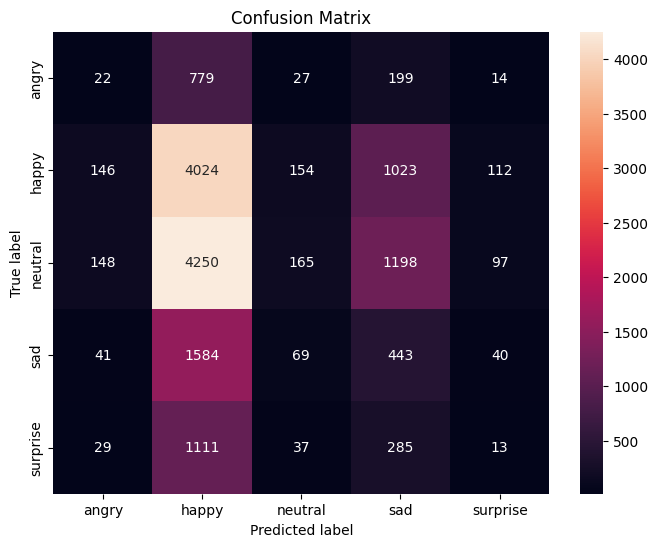

{'Accuracy': 0.2915053091817614,
 'Precision': 0.27754176958607274,
 'Recall': 0.2915053091817614,
 'F1 Score': 0.20461251530264207}

In [46]:
EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'surprise']

y_pred = model.predict(test_generator)
y_pred_classes = y_pred.argmax(axis=1)
y_true = test_generator.classes

evaluate_metric(y_true, y_pred_classes, EMOTIONS)

In [40]:
valid_generator = train_datagen.flow_from_dataframe(
    dataframe = valid_df,
    x_col = 'img_path',
    y_col = 'class_names',
    target_size=(IMG_W, IMG_H),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 16041 validated image filenames belonging to 5 classes.
